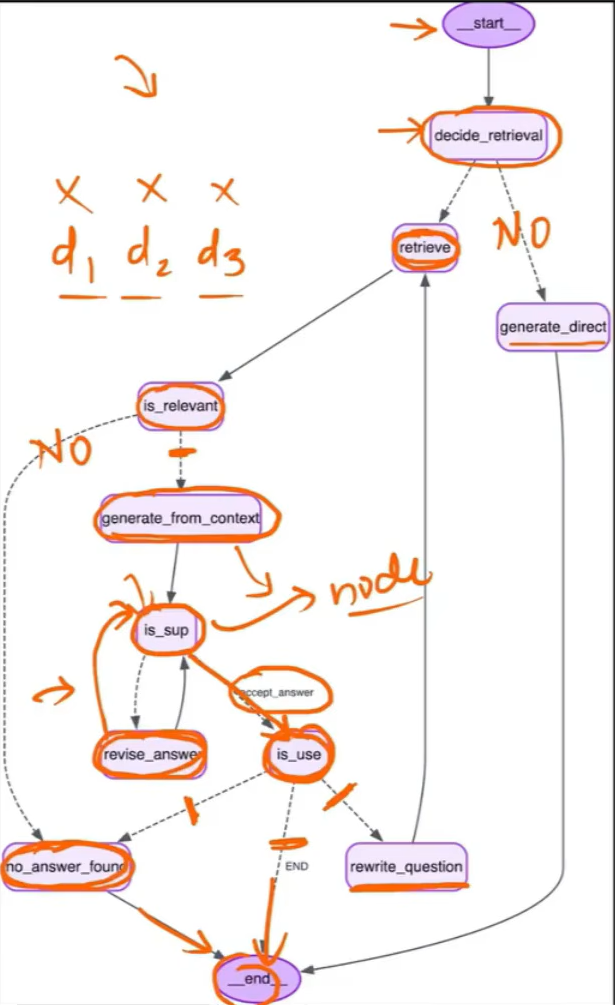

In [16]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

True

In [31]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')
embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')    

In [4]:
ans = llm.invoke('hi how are you')

d:\RAG\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [11]:
ans.content[0]['text']

"Hello! I'm doing well, thank you. How are you doing today? How can I help you?"

In [14]:
# 1. just load the doc

docs = (
    TextLoader("../Document/doc.txt").load()
)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(docs)

vector_store = FAISS.from_documents(chunks, embedding=embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [45]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------

class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    answer: str

In [46]:
# --------------------------------------------------
# find that retrival is needed or not
# --------------------------------------------------

class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


def decide_retrieval(state: State):
    question = state['question']

    res = (decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision) ).invoke({'question': question}).should_retrieve
    
    return {
        'need_retrieval': res
    }

In [47]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content[0]['text']
    }

In [48]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [49]:
def decide_to_route(state:State):

    if state['need_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

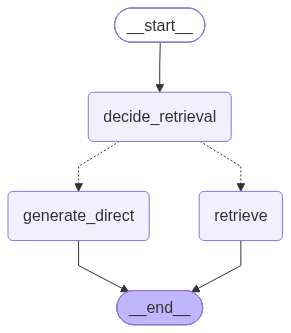

In [50]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    decide_to_route,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge("retrieve", END)  # temporary END for retrieval path

app = g.compile()
app

In [53]:
result = app.invoke(
    {
        "question": "What is sun",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)


The Sun is the star at the center of our solar system. It is a nearly perfect sphere of hot plasma, heated to incandescence by nuclear fusion reactions in its core. 

Here are a few key facts about the Sun:
* **Composition:** It is composed almost entirely of hydrogen and helium.
* **Energy Source:** It generates energy through nuclear fusion, converting hydrogen into helium in its core, which radiates out as light and heat.
* **Role in the Solar System:** Its gravity holds the solar system together, keeping Earth and all the other planets, asteroids, and comets in orbit.
* **Life on Earth:** The Sun's light and heat are essential for life on Earth, driving our planet's weather, ocean currents, seasons, and climate, and making plant life possible through photosynthesis.


In [54]:
result

{'question': 'What is sun',
 'need_retrieval': False,
 'docs': [],
 'answer': "The Sun is the star at the center of our solar system. It is a nearly perfect sphere of hot plasma, heated to incandescence by nuclear fusion reactions in its core. \n\nHere are a few key facts about the Sun:\n* **Composition:** It is composed almost entirely of hydrogen and helium.\n* **Energy Source:** It generates energy through nuclear fusion, converting hydrogen into helium in its core, which radiates out as light and heat.\n* **Role in the Solar System:** Its gravity holds the solar system together, keeping Earth and all the other planets, asteroids, and comets in orbit.\n* **Life on Earth:** The Sun's light and heat are essential for life on Earth, driving our planet's weather, ocean currents, seasons, and climate, and making plant life possible through photosynthesis."}